In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
import pyscisci.all as pyscisci
from brokenaxes import brokenaxes
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import LogLocator
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as ticker
from scipy.stats import norm, ks_2samp
import dask.dataframe as dd
from adjustText import adjust_text
from textwrap import fill
from matplotlib.lines import Line2D
from itertools import combinations
from tqdm import tqdm
from matplotlib.ticker import FuncFormatter
import pickle
import unicodedata
import html
import regex
import re
from rapidfuzz import process as rf_process
from statsmodels.nonparametric.smoothers_lowess import lowess
from rapidfuzz import fuzz
import string
import spacy
tqdm.pandas()  # 注册 tqdm 的 DataFrame 扩展
def to_percent(x, pos):
    return f"{x:.0f}%"  # 保留整数百分比

# 定义字体
EF = FontProperties(family = 'DejaVu Sans')
main_path = r'/home/20250114zmz_kd/'
%matplotlib inline

# Figure1

In [2]:
# With v.s. Without
data_h1 = r'GraduationPaper/RevisetoJournal/R_ex_ld_h1_pred.csv'
d_h1 = pd.read_csv(main_path + data_h1)
print(d_h1 .shape)
d_h1 .columns

(2, 8)


Index(['text_fac_scientist', 'estimate', 'std.error', 'statistic', 'p.value',
       's.value', 'conf.low', 'conf.high'],
      dtype='object')

In [3]:
d_h1 .head(3)

,text_fac_scientist,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
0,NonStaffPart,0.358487,0.031530,11.369867,5.907745e-30,97.095235,0.296690,0.420284
1,StaffPart,0.372379,0.032015,11.631436,2.852572e-31,101.467508,0.309631,0.435127


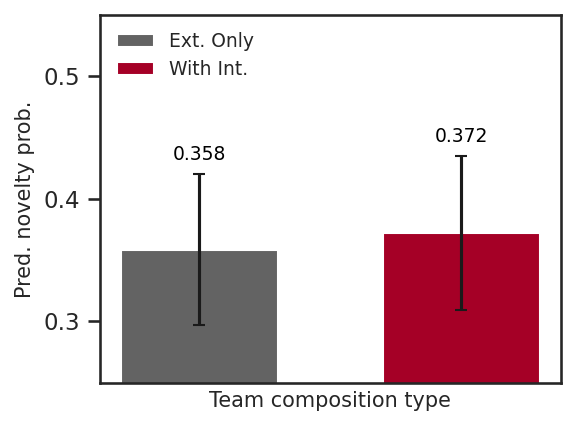

In [4]:
fig = plt.figure(figsize=(4, 3), dpi=150) # 稍微加宽一点以容纳三个点
sns.set(style='ticks', font_scale=1)
outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0])
ax_a = fig.add_subplot(gs1[0])
df = d_h1
df['err_lower'] = df['estimate'] - df['conf.low']
df['err_upper'] = df['conf.high'] - df['estimate']
custom_order = ['NonStaffPart', 'StaffPart']
df['label'] = df['text_fac_scientist'].map({'NonStaffPart':'Ext. Only',
                                            'StaffPart':'With Int.'})
# 2. 将该列转换为有序的 Categorical 类型
df['text_fac_scientist'] = pd.Categorical(df['text_fac_scientist'], categories=custom_order, ordered=True)
# 3. 按照这个顺序排序
df = df.sort_values('text_fac_scientist')
yerr = [df['err_lower'], df['err_upper']]
# 定义颜色 (你可以换成你喜欢的颜色)
colors = ['#636363', '#a50026',] 
# 3. 绘制 Bar 图
bars = ax_a.bar(
    x=df['text_fac_scientist'], height=df['estimate'], yerr=yerr, 
    capsize=3, color=colors, edgecolor=None, label=df['label'], width = 0.6
)
# 3. 绘制 Bar 图
for i, bar in enumerate(bars):
    # 提取柱子的高度 (即你的 estimate)
    val = bar.get_height()
    # 计算文本的高度位置：estimate + 上置信区间的长度 + 一点点微小的偏移量
    text_y_pos = val + df['err_upper'].iloc[i] + 0.008 
    # 添加文本
    ax_a.text(x = bar.get_x() + bar.get_width() / 2, 
              y = text_y_pos, s = f'{val:.3f}',
              ha = 'center', va = 'bottom',
              fontsize = 9,
              color = 'black',)
# 5. 美化坐标轴
ax_a.set_ylabel('Pred. novelty prob.', fontsize=10)
ax_a.set_xlabel('Team composition type', fontsize=10)
ax_a.set_ylim(0.25, 0.55)
ax_a.yaxis.set_major_locator(MultipleLocator(0.1))
# 设置 X 轴刻度标签
ax_a.set_xticks([])
ax_a.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [5]:
# Coll/Part v.s. Without
data_h2 = r'GraduationPaper/RevisetoJournal/R_ex_ld_h2_pred.csv'
d_h2 = pd.read_csv(main_path + data_h2)
print(d_h2 .shape)
d_h2 .columns

(3, 8)


Index(['CoType', 'estimate', 'std.error', 'statistic', 'p.value', 's.value',
       'conf.low', 'conf.high'],
      dtype='object')

In [6]:
d_h2 .head(3)

,CoType,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high
0,Service,0.358558,0.031535,11.370243,5.882342e-30,97.101452,0.296751,0.420365
1,Collaboration,0.378661,0.032247,11.742370,7.728990e-32,103.351419,0.315457,0.441865
2,Participation,0.358955,0.031625,11.350377,7.384392e-30,96.773364,0.296972,0.420939


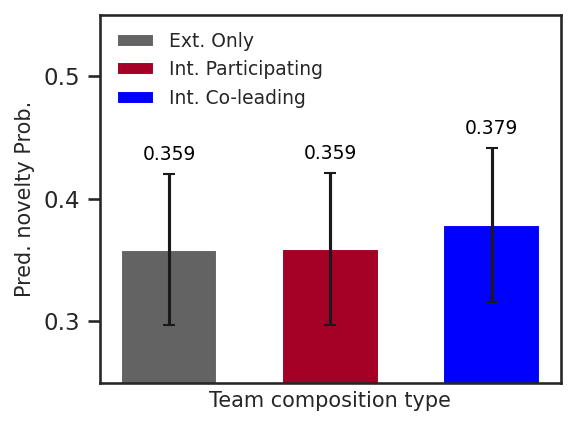

In [7]:
fig = plt.figure(figsize=(4, 3), dpi=150) # 稍微加宽一点以容纳三个点
sns.set(style='ticks', font_scale=1)
outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0])
ax_a = fig.add_subplot(gs1[0])
df = d_h2
df['err_lower'] = df['estimate'] - df['conf.low']
df['err_upper'] = df['conf.high'] - df['estimate']
custom_order = ['Service', 'Participation', 'Collaboration']
df['label'] = df['CoType'].map({'Service':'Ext. Only',
                                            'Participation':'Int. Participating',
                                            'Collaboration':'Int. Co-leading'})
# 2. 将该列转换为有序的 Categorical 类型
df['CoType'] = pd.Categorical(df['CoType'], categories=custom_order, ordered=True)
# 3. 按照这个顺序排序
df = df.sort_values('CoType')
yerr = [df['err_lower'], df['err_upper']]
# 定义颜色 (你可以换成你喜欢的颜色)
colors = ['#636363', '#a50026', 'blue'] 
# 3. 绘制 Bar 图
bars = ax_a.bar(
    x=df['CoType'], height=df['estimate'], yerr=yerr, 
    capsize=3, color=colors, edgecolor=None, label=df['label'], width = 0.6
)
# 3. 绘制 Bar 图
for i, bar in enumerate(bars):
    # 提取柱子的高度 (即你的 estimate)
    val = bar.get_height()
    # 计算文本的高度位置：estimate + 上置信区间的长度 + 一点点微小的偏移量
    text_y_pos = val + df['err_upper'].iloc[i] + 0.008 
    # 添加文本
    ax_a.text(x = bar.get_x() + bar.get_width() / 2, 
              y = text_y_pos, s = f'{val:.3f}',
              ha = 'center', va = 'bottom',
              fontsize = 9,
              color = 'black',)
# 5. 美化坐标轴
ax_a.set_ylabel('Pred. novelty Prob.', fontsize=10)
ax_a.set_xlabel('Team composition type', fontsize=10)
ax_a.set_ylim(0.25, 0.55)
ax_a.yaxis.set_major_locator(MultipleLocator(0.1))
# 设置 X 轴刻度标签
ax_a.set_xticks([])
ax_a.legend(frameon=False, loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [8]:
h1_ps = r'GraduationPaper/RevisetoJournal/R_ex_ld_h1_ps_comp_ratio.csv'
h1ps = pd.read_csv(main_path + h1_ps)
print(h1ps .shape)
h1ps['group'] = 'Physical sci.'
h1ps['label'] = h1ps['contrast'].map({'mean(StaffPart) / mean(NonStaffPart)':'With Int.'})
h1ps .head(3)

(1, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,text_fac_scientist,mean(StaffPart) / mean(NonStaffPart),1.035422,0.006776,152.80337,0,inf,1.022141,1.048703,0.283728,0.295801,0.283728,Physical sci.,With Int.


In [9]:
h1_ls = r'GraduationPaper/RevisetoJournal/R_ex_ld_h1_ls_comp_ratio.csv'
h1ls = pd.read_csv(main_path + h1_ls)
print(h1ls .shape)
h1ls['group'] = 'Life sci.'
h1ls['label'] = h1ls['contrast'].map({'mean(StaffPart) / mean(NonStaffPart)':'With Int.'})
h1ls .head(3)

(1, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,text_fac_scientist,mean(StaffPart) / mean(NonStaffPart),1.065502,0.014474,73.61439,0,inf,1.037133,1.09387,0.316404,0.345431,0.316404,Life sci.,With Int.


In [10]:
h1_hs = r'GraduationPaper/RevisetoJournal/R_ex_ld_h1_hs_comp_ratio.csv'
h1hs = pd.read_csv(main_path + h1_hs)
print(h1hs .shape)
h1hs['group'] = 'Health sci.'
h1hs['label'] = h1hs['contrast'].map({'mean(StaffPart) / mean(NonStaffPart)':'With Int.'})
h1hs .head(3)

(1, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,text_fac_scientist,mean(StaffPart) / mean(NonStaffPart),1.16192,0.04169,27.870661,6.052872e-171,565.452084,1.08021,1.24363,0.708248,0.781646,0.708248,Health sci.,With Int.


In [11]:
h1_nps = r'GraduationPaper/RevisetoJournal/R_ex_ld_h1_nps_comp_ratio.csv'
h1nps = pd.read_csv(main_path + h1_nps)
print(h1nps .shape)
h1nps['group'] = 'non-Physical sci.'
h1nps['label'] = h1nps['contrast'].map({'mean(StaffPart) / mean(NonStaffPart)':'With Int.'})
h1nps .head(3)

(1, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,text_fac_scientist,mean(StaffPart) / mean(NonStaffPart),1.166542,0.037747,30.903838,1.060737e-209,694.197905,1.092559,1.240526,0.670948,0.736958,0.670948,non-Physical sci.,With Int.


In [12]:
h2_ps = r'GraduationPaper/RevisetoJournal/R_ex_ld_h2_ps_comp_ratio.csv'
h2ps = pd.read_csv(main_path + h2_ps)
print(h2ps .shape)
h2ps['group'] = 'Physical sci.'
h2ps['label'] = h2ps['contrast'].map({'mean(Collaboration) / mean(Service)':'Int. Co-leading',
                                      'mean(Participation) / mean(Service)':'Int. Participating'})
h2ps .head(3)

(2, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,CoType,mean(Collaboration) / mean(Service),1.049506,0.007822,134.170590,0,inf,1.034175,1.064837,0.283434,0.300327,0.283434,Physical sci.,Int. Co-leading
1,CoType,mean(Participation) / mean(Service),1.004135,0.009546,105.190607,0,inf,0.985425,1.022844,0.283434,0.284837,0.283434,Physical sci.,Int. Participating


In [13]:
h2_ls = r'GraduationPaper/RevisetoJournal/R_ex_ld_h2_ls_comp_ratio.csv'
h2ls = pd.read_csv(main_path + h2_ls)
print(h2ps .shape)
h2ls['group'] = 'Life sci.'
h2ls['label'] = h2ls['contrast'].map({'mean(Collaboration) / mean(Service)':'Int. Co-leading',
                                      'mean(Participation) / mean(Service)':'Int. Participating'})
h2ls .head(3)

(2, 14)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,CoType,mean(Collaboration) / mean(Service),1.056350,0.015034,70.263281,0,inf,1.026883,1.085816,0.316494,0.341398,0.316494,Life sci.,Int. Co-leading
1,CoType,mean(Participation) / mean(Service),1.088891,0.022209,49.028985,0,inf,1.045362,1.132420,0.316494,0.356166,0.316494,Life sci.,Int. Participating


In [14]:
h2_hs = r'GraduationPaper/RevisetoJournal/R_ex_ld_h2_hs_comp_ratio.csv'
h2hs = pd.read_csv(main_path + h2_hs)
print(h2hs .shape)
h2hs['group'] = 'Health sci.'
h2hs['label'] = h2hs['contrast'].map({'mean(Collaboration) / mean(Service)':'Int. Co-leading',
                                      'mean(Participation) / mean(Service)':'Int. Participating'})
h2hs .head(3)

(2, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,CoType,mean(Collaboration) / mean(Service),1.145328,0.039036,29.340381,3.169837e-189,626.180001,1.068819,1.221837,0.708386,0.774684,0.708386,Health sci.,Int. Co-leading
1,CoType,mean(Participation) / mean(Service),1.198086,0.054296,22.065782,6.739312e-108,356.015633,1.091668,1.304505,0.708386,0.796814,0.708386,Health sci.,Int. Participating


In [15]:
h2_nps = r'GraduationPaper/RevisetoJournal/R_ex_ld_h2_nps_comp_ratio.csv'
h2nps = pd.read_csv(main_path + h2_nps)
print(h2nps .shape)
h2nps['group'] = 'non-Physical sci.'
h2nps['label'] = h2nps['contrast'].map({'mean(Collaboration) / mean(Service)':'Int. Co-leading',
                                      'mean(Participation) / mean(Service)':'Int. Participating'})
h2nps .head(3)

(2, 12)


,term,contrast,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,group,label
0,CoType,mean(Collaboration) / mean(Service),1.147427,0.036647,31.310674,3.339641e-215,712.474847,1.075601,1.219253,0.671166,0.730068,0.671166,non-Physical sci.,Int. Co-leading
1,CoType,mean(Participation) / mean(Service),1.207672,0.051314,23.534842,1.794850e-122,404.431364,1.107098,1.308246,0.671166,0.751957,0.671166,non-Physical sci.,Int. Participating


In [16]:
m = pd.concat([h1ps, h1nps, h1ls, h1hs, h2ps, h2nps, h2ls, h2hs,], ignore_index = True)
print(m .shape)
m .columns

(12, 14)


Index(['term', 'contrast', 'estimate', 'std.error', 'statistic', 'p.value',
       's.value', 'conf.low', 'conf.high', 'predicted_lo', 'predicted_hi',
       'predicted', 'group', 'label'],
      dtype='object')

In [17]:
print(m['group'].unique())
print(m['label'].unique())

['Physical sci.' 'non-Physical sci.' 'Life sci.' 'Health sci.']
['With Int.' 'Int. Co-leading' 'Int. Participating']


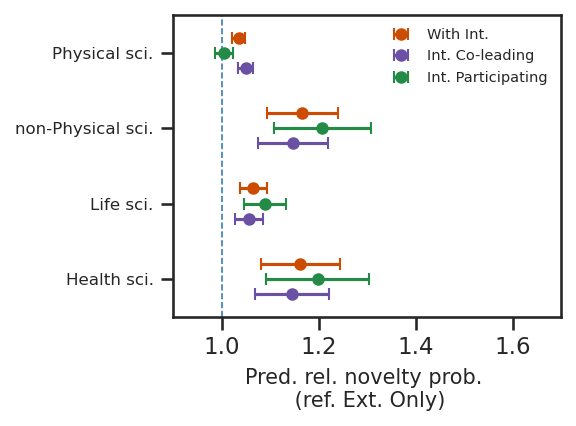

In [18]:
fig = plt.figure(figsize=(4, 3), dpi=150) # 稍微加宽一点以容纳三个点
sns.set(style='ticks', font_scale=1)
outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0])
ax1 = fig.add_subplot(gs1[0])
# 1. 定义 Y 轴的主分组顺序 (从下到上，或者从上到下，取决于你想要的视觉顺序)
group_order = ['Health sci.', 'Life sci.', 'non-Physical sci.', 'Physical sci.']
# 2. 定义三类 Label 的颜色和相对 Y 轴的偏移量 (错开显示)
labels_config = {
    'With Int.': {'color': '#cc4c02', 'offset': 0.2},          # 最上方
    'Int. Co-leading': {'color': '#6a51a3', 'offset': -0.2},    # 中间
    'Int. Participating': {'color': '#238b45', 'offset': -0.0} # 最下方
}
# 3. 循环遍历三种 Label，并分别进行过滤和画图
for label_name, config in labels_config.items():
    # 过滤出当前 label 的子集
    df_sub = m[m['label'] == label_name]   
    for _, row in df_sub.iterrows():
        # 确保当前的 group 在我们定义的 order 列表中
        if row['group'] in group_order:
            # 找到该组的基础 Y 坐标
            y_base = group_order.index(row['group'])
            # 加上偏移量
            y_pos = y_base + config['offset']
            # 计算误差棒长度: [左侧误差, 右侧误差]
            # 注意: xerr 接收的是距离中心点的相对长度，而不是绝对坐标
            err_low = row['estimate'] - row['conf.low']
            err_high = row['conf.high'] - row['estimate']
            # 画带误差棒的点
            ax1.errorbar(
                x=row['estimate'], y=y_pos, xerr=[[err_low], [err_high]], fmt='o', 
                color=config['color'], capsize=3, markersize=5, label=label_name
            )
# 4. Y 轴格式化 (添加换行符，设置刻度)
group_wrapped = [fill(label, width=20) for label in group_order]  # 每行最多12个字符
ax1.set_yticks(range(len(group_wrapped)))
ax1.set_yticklabels(group_wrapped, fontsize = 8)
ax1.set_ylim(-0.5, len(group_order) - 0.5)
# 5. X 轴格式化和辅助线
ax1.set_xlabel('Pred. rel. novelty prob. \n (ref. Ext. Only)', fontsize = 10)
# 根据你的实际数据，如果是对数/标准回归系数画 0，如果是优势比(OR)画 1
ax1.axvline(1, color='#377eb8', linestyle='--', linewidth=0.8) 
ax1.set_xlim(0.9, 1.7)
ax1.xaxis.set_major_locator(MultipleLocator(0.2)) # 根据你的数据大小调整 X 轴刻度间隔
handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ordered_legend_handles = [by_label[k] for k in labels_config.keys() if k in by_label]
ax1.legend(ordered_legend_handles, labels_config.keys(), frameon=False, loc='upper right',fontsize=7)

plt.tight_layout()
plt.show()

In [19]:
psm = r'GraduationPaper/RevisetoJournal/ex_ld_PSM/ex_ld_psm_results.xlsx'
p = pd.read_excel(main_path + psm)
print(p .shape)
p .columns

(3, 4)


Index(['Type', 'ATT', 'low', 'up'], dtype='object')

In [20]:
p['Type'].unique()

array(['With Int.', 'Int. Participating', 'Int. Co-leading'], dtype=object)

In [21]:
p['Type'] = p['Type'].map({'With Int.':'With In-house scit.', 'Int. Participating' : 'In-house scit. Participating', 'Int. Co-leading' : 'In-house scit. Co-leading'})

p.columns

Index(['Type', 'ATT', 'low', 'up'], dtype='object')

In [22]:
p['Type'].unique()

array(['With In-house scit.', 'In-house scit. Participating',
       'In-house scit. Co-leading'], dtype=object)

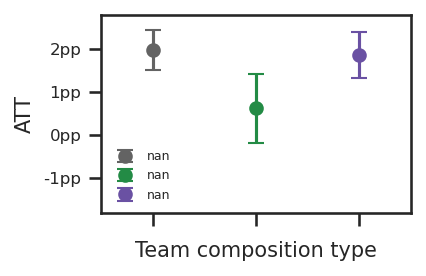

In [23]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import pandas as pd

fig = plt.figure(figsize=(3, 2), dpi=150)
sns.set(style='ticks', font_scale=1)

outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=outer[0])
ax_a = fig.add_subplot(gs1[0])

# 建议加上 .copy()，避免在切片上操作报 SettingWithCopyWarning
df = p
# 1. 计算误差的绝对长度 (对应你现在的列名: ATT, low, up)
df['err_lower'] = df['ATT'] - df['low']
df['err_upper'] = df['up'] - df['ATT']
# 2. 排序与分类
custom_order = ['With Int.', 'Int. Participating', 'Int. Co-leading']
df['Type'] = pd.Categorical(df['Type'], categories=custom_order, ordered=True)
df = df.sort_values('Type').reset_index(drop=True) # 重置索引方便后续循环画图
# 3. 定义颜色
colors = ['#636363', '#238b45', '#6a51a3'] # 灰、绿、紫
# 4. 绘制带误差棒的点图 (Point Plot)
for i, row in df.iterrows():
    # 画误差点
    ax_a.errorbar(
        x=i,                                          
        y=row['ATT'],                                 
        yerr=[[row['err_lower']], [row['err_upper']]],
        fmt='o',                                      
        color=colors[i],
        capsize=4,                                    
        markersize=6,                                 
        label=row['Type']         
    )
# 6. 美化坐标轴
ax_a.set_ylabel('ATT', fontsize=10) # 根据你的 ATT 含义可修改
ax_a.set_xlabel('Team composition type', fontsize=10)
ax_a.set_xlim(-0.5, 2.5)
ax_a.set_ylim(-0.018, 0.028)
ax_a.set_yticks([-0.01, 0, 0.01, 0.02])
ax_a.set_yticklabels(["-1pp", '0pp', '1pp', '2pp'], fontsize = 8)
# ax_a.yaxis.set_major_locator(MultipleLocator(0.01)) # 根据你的数据大小调整 X 轴刻度间隔

# 设置 X 轴刻度及标签
ax_a.set_xticks(range(len(df)))
ax_a.set_xticklabels([]) # 隐藏 X 轴原本的刻度文字，依靠图例区分
ax_a.legend(frameon=False, loc='lower left', fontsize=6)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3157758/1648922312.py:178: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


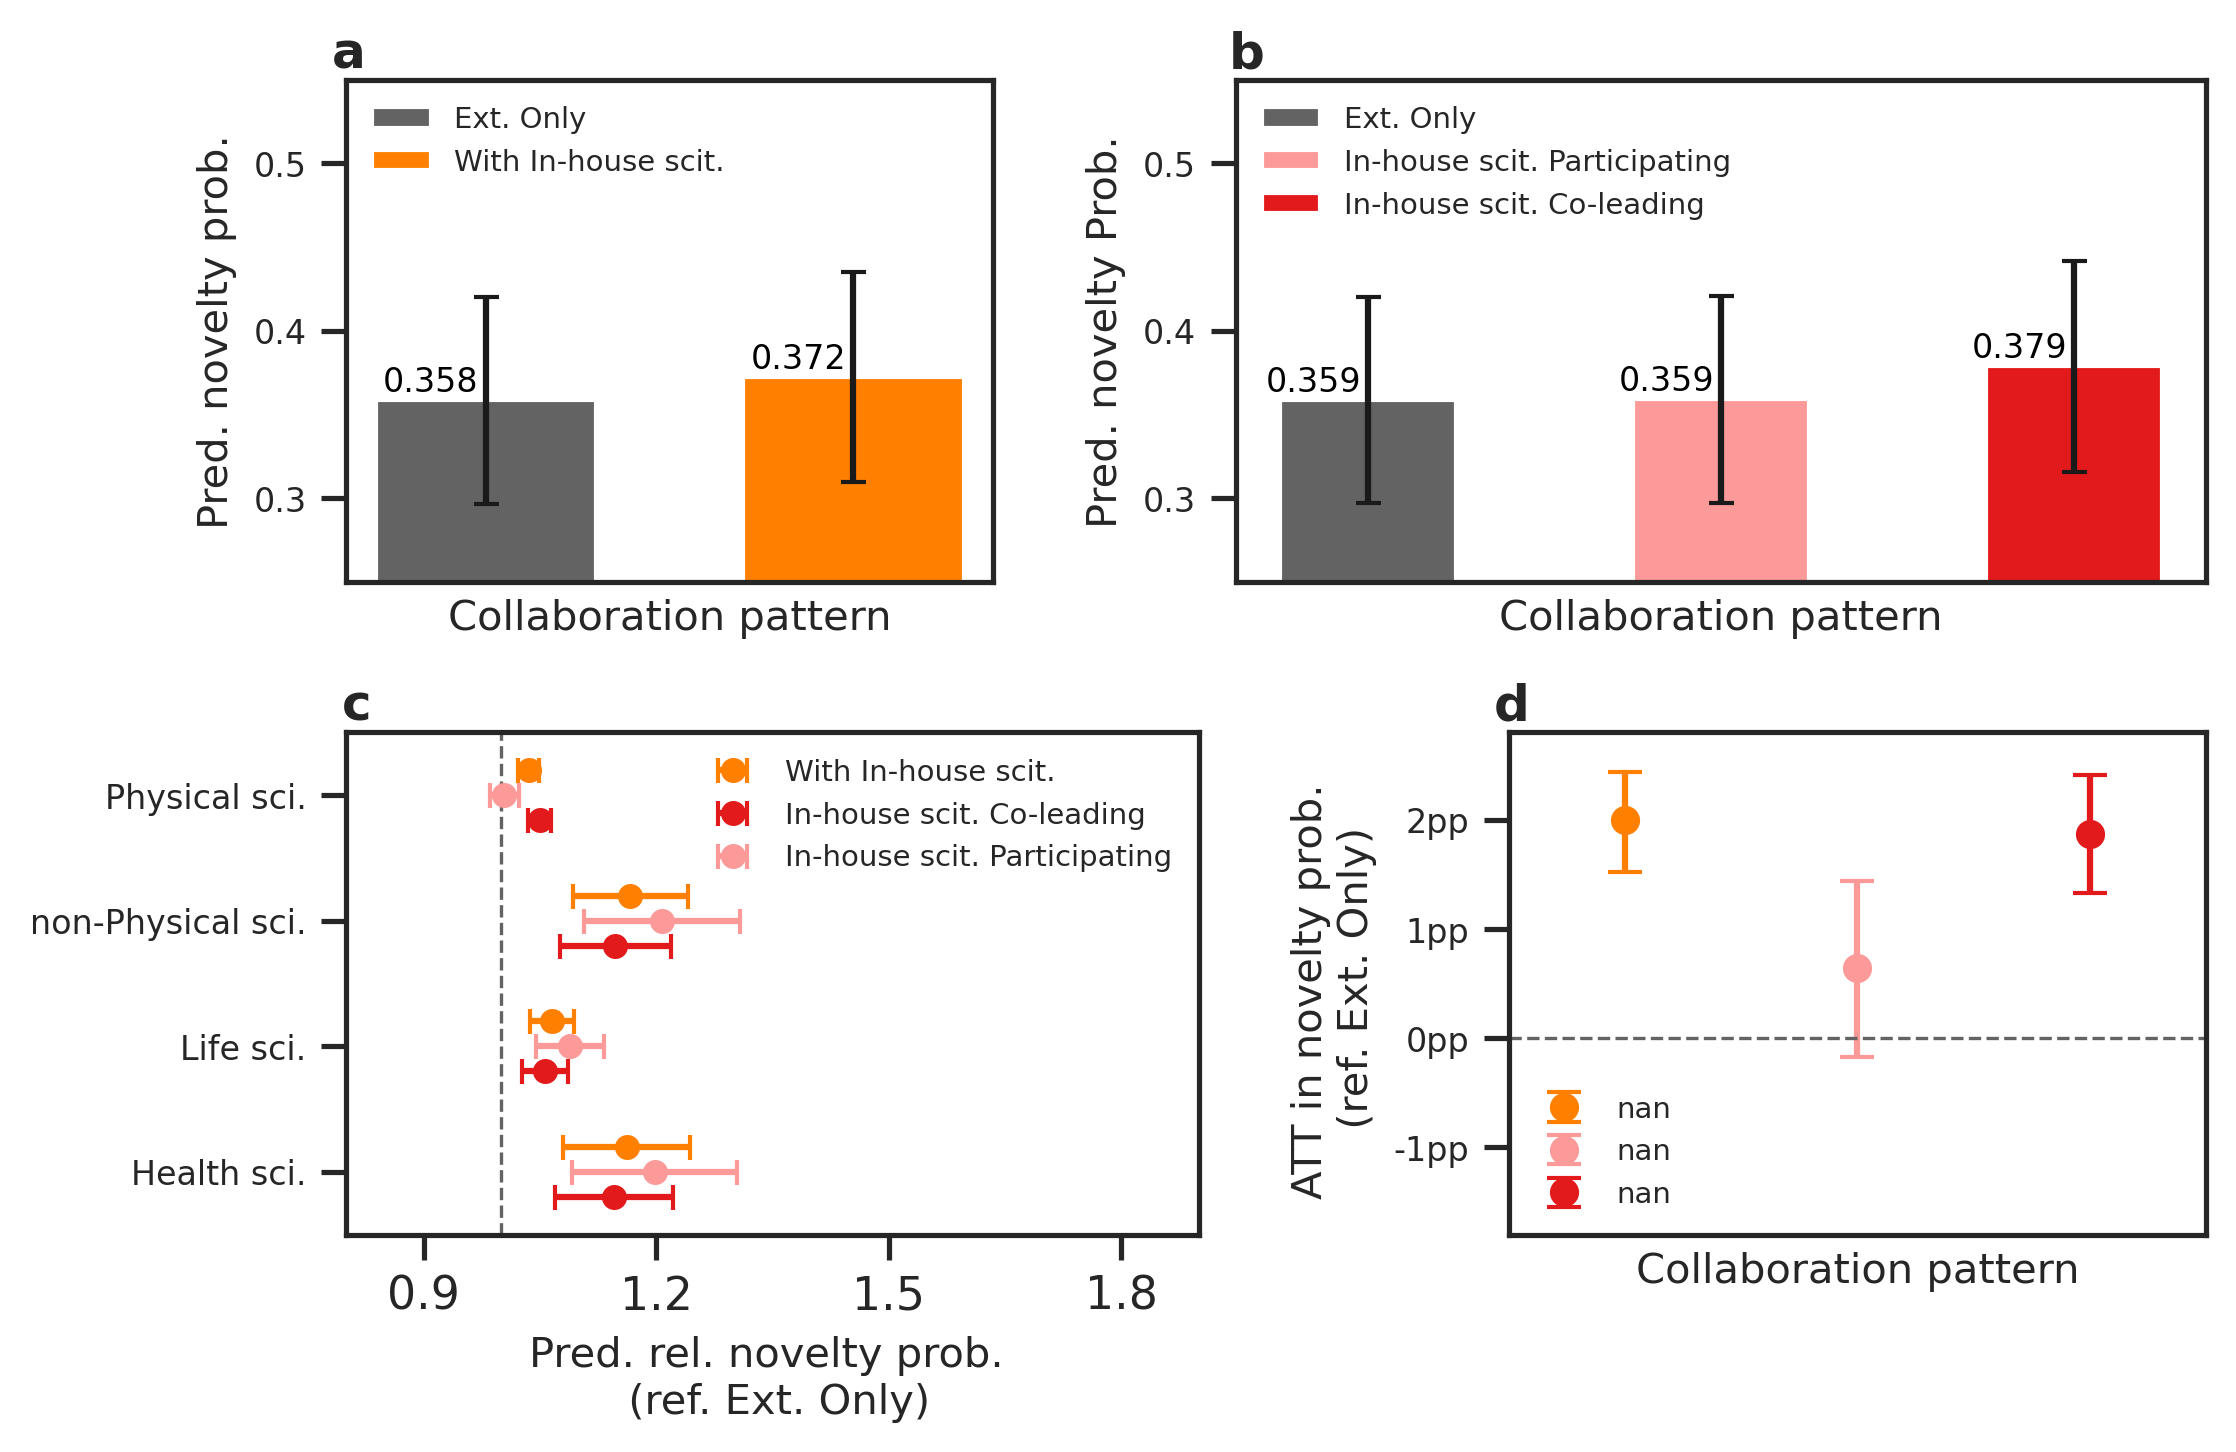

In [25]:
fig = plt.figure(figsize=(8, 5), dpi=300) # 稍微加宽一点以容纳三个点
sns.set(style='ticks', font_scale=1)
outer = gridspec.GridSpec(2, 1, hspace = 0.3)

gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], width_ratios = [0.8, 1.2], wspace = 0.3)
ax1 = fig.add_subplot(gs1[0])
df = d_h1
df['err_lower'] = df['estimate'] - df['conf.low']
df['err_upper'] = df['conf.high'] - df['estimate']
custom_order = ['NonStaffPart', 'StaffPart']
df['label'] = df['text_fac_scientist'].map({'NonStaffPart':'Ext. Only',
                                            'StaffPart':'With In-house scit.'})
# 2. 将该列转换为有序的 Categorical 类型
df['text_fac_scientist'] = pd.Categorical(df['text_fac_scientist'], categories=custom_order, ordered=True)
# 3. 按照这个顺序排序
df = df.sort_values('text_fac_scientist')
yerr = [df['err_lower'], df['err_upper']]
# 定义颜色 (你可以换成你喜欢的颜色)
colors = ['#636363', '#ff7f00',] 
# 3. 绘制 Bar 图
bars = ax1.bar(x=df['text_fac_scientist'], height=df['estimate'], yerr=yerr, 
               capsize=3, color=colors, edgecolor=None, label=df['label'], width = 0.6
)
for i, bar in enumerate(bars):
    # 提取柱子的高度 (即你的 estimate)
    val = bar.get_height()
    # 计算文本的高度位置：estimate + 上置信区间的长度 + 一点点微小的偏移量
    text_y_pos = val + 0.001
    # 添加文本
    ax1.text(x = bar.get_x() + bar.get_width()/4, y = text_y_pos, s = f'{val:.3f}',
             ha = 'center', va = 'bottom',fontsize = 8,color = 'black',)
# 5. 美化坐标轴
ax1.set_ylabel('Pred. novelty prob.', fontsize=10)
ax1.set_xlabel('Collaboration pattern', fontsize=10)
ax1.set_ylim(0.25, 0.55)
ax1.tick_params(axis='y', labelsize=8)
ax1.yaxis.set_major_locator(MultipleLocator(0.1))
# 设置 X 轴刻度标签
ax1.set_xticks([])
ax1.legend(frameon=False, loc='upper left', fontsize=7)

ax2 = fig.add_subplot(gs1[1])
df = d_h2
df['err_lower'] = df['estimate'] - df['conf.low']
df['err_upper'] = df['conf.high'] - df['estimate']
custom_order = ['Service', 'Participation', 'Collaboration']
df['label'] = df['CoType'].map({'Service':'Ext. Only',
                                            'Participation':'In-house scit. Participating',
                                            'Collaboration':'In-house scit. Co-leading'})
# 2. 将该列转换为有序的 Categorical 类型
df['CoType'] = pd.Categorical(df['CoType'], categories=custom_order, ordered=True)
# 3. 按照这个顺序排序
df = df.sort_values('CoType')
yerr = [df['err_lower'], df['err_upper']]
# 定义颜色 (你可以换成你喜欢的颜色)
colors = ['#636363', '#fb9a99', '#e31a1c'] 
# 3. 绘制 Bar 图
bars = ax2.bar(
    x=df['CoType'], height=df['estimate'], yerr=yerr, 
    capsize=3, color=colors, edgecolor=None, label=df['label'], width = 0.5
)
# 3. 绘制 Bar 图
for i, bar in enumerate(bars):
    # 提取柱子的高度 (即你的 estimate)
    val = bar.get_height()
    # 计算文本的高度位置：estimate + 上置信区间的长度 + 一点点微小的偏移量
    text_y_pos = val + 0.001
    # 添加文本
    ax2.text(x = bar.get_x() + bar.get_width() / 4 - 0.03, y = text_y_pos, s = f'{val:.3f}',
             ha = 'center', va = 'bottom',fontsize = 8,color = 'black',)
# 5. 美化坐标轴
ax2.set_ylabel('Pred. novelty Prob.', fontsize=10)
ax2.set_xlabel('Collaboration pattern', fontsize=10)
ax2.set_ylim(0.25, 0.55)
ax2.yaxis.set_major_locator(MultipleLocator(0.1))
ax2.tick_params(axis='y', labelsize=8)
# 设置 X 轴刻度标签
ax2.set_xticks([])
ax2.legend(frameon=False, loc='upper left', fontsize=7)

gs2 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[1], width_ratios = [1.1, 0.9], wspace = 0.4)
ax3 = fig.add_subplot(gs2[0])

group_order = ['Health sci.', 'Life sci.', 'non-Physical sci.', 'Physical sci.']
# 2. 定义三类 Label 的颜色和相对 Y 轴的偏移量 (错开显示)
labels_config = {
    'With Int.': {'color': '#ff7f00', 'offset': 0.2},          # 最上方
    'Int. Co-leading': {'color': '#e31a1c', 'offset': -0.2},    # 中间
    'Int. Participating': {'color': '#fb9a99', 'offset': -0.0} # 最下方
}
newlabel = {'With Int.':'With In-house scit.', 'Int. Participating' : 'In-house scit. Participating', 'Int. Co-leading' : 'In-house scit. Co-leading'}
# 3. 循环遍历三种 Label，并分别进行过滤和画图
for label_name, config in labels_config.items():
    # 过滤出当前 label 的子集
    df_sub = m[m['label'] == label_name]   
    for _, row in df_sub.iterrows():
        # 确保当前的 group 在我们定义的 order 列表中
        if row['group'] in group_order:
            # 找到该组的基础 Y 坐标
            y_base = group_order.index(row['group'])
            # 加上偏移量
            y_pos = y_base + config['offset']
            # 计算误差棒长度: [左侧误差, 右侧误差]
            # 注意: xerr 接收的是距离中心点的相对长度，而不是绝对坐标
            err_low = row['estimate'] - row['conf.low']
            err_high = row['conf.high'] - row['estimate']
            # 画带误差棒的点
            ax3.errorbar(
                x=row['estimate'], y=y_pos, xerr=[[err_low], [err_high]], fmt='o', 
                color=config['color'], capsize=3, markersize=5, label=newlabel[label_name]
            )
# 4. Y 轴格式化 (添加换行符，设置刻度)
group_wrapped = [fill(label, width=20) for label in group_order]  # 每行最多12个字符
ax3.set_yticks(range(len(group_wrapped)))
ax3.set_yticklabels(group_wrapped, fontsize = 8)
ax3.set_ylim(-0.5, len(group_order) - 0.5)
# 5. X 轴格式化和辅助线
ax3.set_xlabel('Pred. rel. novelty prob. \n (ref. Ext. Only)', fontsize = 10)
# 根据你的实际数据，如果是对数/标准回归系数画 0，如果是优势比(OR)画 1
ax3.axvline(1, color='#636363', linestyle='--', linewidth=0.8) 
ax3.set_xlim(0.8, 1.9)
ax3.xaxis.set_major_locator(MultipleLocator(0.3)) # 根据你的数据大小调整 X 轴刻度间隔
# 2. 修正 Legend 提取逻辑
handles, labels = ax3.get_legend_handles_labels()
# 去重：只保留第一次出现的 handle 和 label
by_label = dict(zip(labels, handles)) 
# 3. 按照你想要的逻辑顺序排列图例
# 注意：by_label 的键现在是 newlabel 的值 (长名字)
ordered_labels = [newlabel[k] for k in labels_config.keys()]
ordered_handles = [by_label[k] for k in ordered_labels if k in by_label]

# 4. 生成图例
ax3.legend(ordered_handles, ordered_labels, frameon=False, loc='upper right', fontsize=7)

ax4 = fig.add_subplot(gs2[1])
# 建议加上 .copy()，避免在切片上操作报 SettingWithCopyWarning
df = p
# 1. 计算误差的绝对长度 (对应你现在的列名: ATT, low, up)
df['err_lower'] = df['ATT'] - df['low']
df['err_upper'] = df['up'] - df['ATT']
# 2. 排序与分类
custom_order = ['With In-house scit.', 'In-house scit. Participating', 'In-house scit. Co-leading']
df['Type'] = pd.Categorical(df['Type'], categories=custom_order, ordered=True)
df = df.sort_values('Type').reset_index(drop=True) # 重置索引方便后续循环画图
# 3. 定义颜色
colors = ['#ff7f00', '#fb9a99', '#e31a1c']
# 4. 绘制带误差棒的点图 (Point Plot)
for i, row in df.iterrows():
    # 画误差点
    ax4.errorbar(
        x=i,                                          
        y=row['ATT'],                                 
        yerr=[[row['err_lower']], [row['err_upper']]],
        fmt='o',                                      
        color=colors[i],
        capsize=4,                                    
        markersize=6,                                 
        label=row['Type']         
    )
# 6. 美化坐标轴
ax4.set_ylabel('ATT in novelty prob. \n (ref. Ext. Only)', fontsize=10) # 根据你的 ATT 含义可修改
ax4.set_xlabel('Collaboration pattern', fontsize=10)
ax4.set_xlim(-0.5, 2.5)
ax4.set_ylim(-0.018, 0.028)
ax4.set_yticks([-0.01, 0, 0.01, 0.02])
ax4.axhline(0, color='#636363', linestyle='--', linewidth=0.8) 
ax4.set_yticklabels(["-1pp", '0pp', '1pp', '2pp'], fontsize = 8)
# ax4.yaxis.set_major_locator(MultipleLocator(0.01)) # 根据你的数据大小调整 X 轴刻度间隔
# 设置 X 轴刻度及标签
ax4.set_xticks([])
ax4.legend(frameon=False, loc='lower left', fontsize=7)

ax_num = [ax1, ax2, ax3, ax4]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(0.03, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')   
plt.tight_layout()
plt .savefig(main_path + r'GraduationPaper/RevisetoJournal/Figure2.svg', bbox_inches='tight')
plt.show()

# Figure 2, H3

In [26]:
part_ratio = r'GraduationPaper/RevisetoJournal/R_ex_ld_h3_pred_pratio.csv'
pro = pd.read_csv(main_path + part_ratio)
e0 = pro['estimate'].iloc[0]
cl0 = pro['conf.low'].iloc[0]
ch0 = pro['conf.high'].iloc[0]
pro['e0'] = pro['estimate']/e0
pro['cl0'] = pro['conf.low']/cl0
pro['ch0'] = pro['conf.high']/ch0
print(pro .shape)
pro .columns

(50, 7)


Index(['ratio_fac_scientist', 'estimate', 'conf.low', 'conf.high', 'e0', 'cl0',
       'ch0'],
      dtype='object')

In [27]:
pro

,ratio_fac_scientist,estimate,conf.low,conf.high,e0,cl0,ch0
0,0.000000,0.248203,0.197484,0.306966,1.000000,1.000000,1.000000
1,0.020030,0.249665,0.198735,0.308620,1.005890,1.006336,1.005388
2,0.040060,0.251067,0.199932,0.310209,1.011540,1.012401,1.010566
3,0.060091,0.252409,0.201077,0.311733,1.016946,1.018194,1.015529
4,0.080121,0.253690,0.202167,0.313188,1.022106,1.023716,1.020272
5,0.100151,0.254909,0.203204,0.314576,1.027017,1.028965,1.024791
6,0.120181,0.256065,0.204186,0.315893,1.031676,1.033941,1.029081
7,0.140212,0.257158,0.205115,0.317138,1.036082,1.038643,1.033139
8,0.160242,0.258188,0.205989,0.318312,1.040231,1.043071,1.036962
9,0.180272,0.259154,0.206809,0.319412,1.044122,1.047223,1.040547


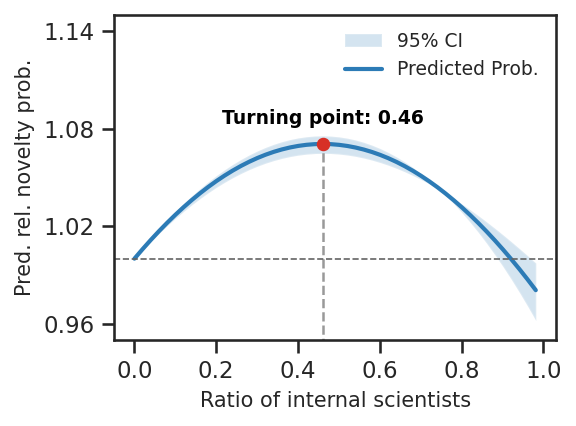

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. 设置画布大小和高分辨率学术风
fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
sns.set(style='ticks', font_scale=1)
# 定义主色调 (经典的学术蓝)
main_color = '#2c7bb6'
df = pro
# 2. 绘制 95% 置信区间的阴影带 (fill_between)
# 这一步要先画，这样阴影会在曲线的下层，不会遮挡实线
ax.fill_between(
    x=df['ratio_fac_scientist'], 
    y1=df['cl0'], 
    y2=df['ch0'], 
    color=main_color, 
    alpha=0.2,               # 透明度设为 0.2，显得轻盈
    edgecolor=None,          # 阴影边缘不要线条
    label='95% CI'
)
# 3. 绘制核心预测曲线 (plot)
ax.plot(
    df['ratio_fac_scientist'], 
    df['e0'], 
    color=main_color, 
    linewidth=2,           # 稍微加粗，突出主线
    label='Predicted Prob.'
)
peak_idx = df['e0'].idxmax()
optimal_x = df.loc[peak_idx, 'ratio_fac_scientist']
max_y = df.loc[peak_idx, 'e0']
ax.vlines(x=optimal_x, ymin=-1, ymax=max_y, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
ax.scatter(optimal_x, max_y, color='#d73027', s=30, zorder=5)
ax.text(
    x=optimal_x, 
    y=max_y+0.01, 
    s=f'Turning point: {optimal_x:.2f}', # 保留两位小数
    ha='center', 
    va='bottom', 
    fontsize=9, 
    color='black',
    fontweight='bold'
)
# 4. 坐标轴与文字美化
ax.set_xlabel('Ratio of internal scientists', fontsize=10)
ax.set_ylabel('Pred. rel. novelty prob.', fontsize=10)
# 根据你的实际数据概率范围调整 Y 轴，比如:
ax.set_ylim(0.95, 1.15) 
ax.axhline(1, color='#636363', linestyle='--', linewidth=0.8) 
ax.yaxis.set_major_locator(MultipleLocator(0.06))
# 6. 图例设置
ax.legend(frameon=False, loc='best', fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
lead_ratio = r'GraduationPaper/RevisetoJournal/R_ex_ld_h3_pred_lratio.csv'
lro = pd.read_csv(main_path + lead_ratio)
e0 = lro['estimate'].iloc[0]
cl0 = lro['conf.low'].iloc[0]
ch0 = lro['conf.high'].iloc[0]
lro['e0'] = lro['estimate']/e0
lro['cl0'] = lro['conf.low']/cl0
lro['ch0'] = lro['conf.high']/ch0
print(lro .shape)
lro .columns

(50, 7)


Index(['fac_scientist_lead_ratio', 'estimate', 'conf.low', 'conf.high', 'e0',
       'cl0', 'ch0'],
      dtype='object')

In [30]:
lro[lro['e0']<1.1]

,fac_scientist_lead_ratio,estimate,conf.low,conf.high,e0,cl0,ch0
0,0.000000,0.228258,0.139939,0.349656,1.000000,1.000000,1.000000
1,0.019922,0.229123,0.140534,0.350765,1.003790,1.004252,1.003171
2,0.039845,0.229935,0.141090,0.351810,1.007345,1.008224,1.006159
3,0.059767,0.230692,0.141606,0.352789,1.010664,1.011916,1.008959
4,0.079689,0.231395,0.142084,0.353702,1.013745,1.015328,1.011569
5,0.099611,0.232044,0.142523,0.354546,1.016587,1.018463,1.013984
6,0.119534,0.232638,0.142922,0.355322,1.019188,1.021320,1.016203
7,0.139456,0.233176,0.143284,0.356028,1.021546,1.023901,1.018223
8,0.159378,0.233659,0.143606,0.356664,1.023661,1.026206,1.020040
9,0.179300,0.234086,0.143890,0.357228,1.025531,1.028235,1.021654


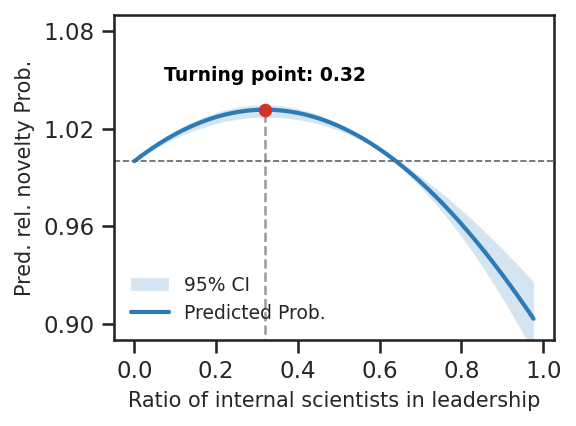

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1. 设置画布大小和高分辨率学术风
fig, ax = plt.subplots(figsize=(4, 3), dpi=150)
sns.set(style='ticks', font_scale=1)
# 定义主色调 (经典的学术蓝)
main_color = '#2c7bb6'
df = lro
# 2. 绘制 95% 置信区间的阴影带 (fill_between)
# 这一步要先画，这样阴影会在曲线的下层，不会遮挡实线
ax.fill_between(
    x=df['fac_scientist_lead_ratio'], 
    y1=df['cl0'], 
    y2=df['ch0'], 
    color=main_color, 
    alpha=0.2,               # 透明度设为 0.2，显得轻盈
    edgecolor=None,          # 阴影边缘不要线条
    label='95% CI'
)
# 3. 绘制核心预测曲线 (plot)
ax.plot(
    df['fac_scientist_lead_ratio'], 
    df['e0'], 
    color=main_color, 
    linewidth=2,           # 稍微加粗，突出主线
    label='Predicted Prob.'
)
peak_idx = df['e0'].idxmax()
optimal_x = df.loc[peak_idx, 'fac_scientist_lead_ratio']
max_y = df.loc[peak_idx, 'e0']
ax.vlines(x=optimal_x, ymin=0.05, ymax=max_y, color='gray', linestyle='--', linewidth=1.2, alpha=0.8, zorder=1)
ax.scatter(optimal_x, max_y, color='#d73027', s=30, zorder=5)
ax.text(
    x=optimal_x, 
    y=max_y + 0.015, 
    s=f'Turning point: {optimal_x:.2f}', # 保留两位小数
    ha='center', 
    va='bottom', 
    fontsize=9, 
    color='black',
    fontweight='bold'
)
# 4. 坐标轴与文字美化
ax.set_xlabel('Ratio of internal scientists in leadership', fontsize=10)
ax.set_ylabel('Pred. rel. novelty Prob.', fontsize=10)
# 根据你的实际数据概率范围调整 Y 轴，比如:
ax.set_ylim(0.89, 1.09) 
ax.axhline(1, color='#636363', linestyle='--', linewidth=0.8) 
ax.yaxis.set_major_locator(MultipleLocator(0.06))

# 6. 图例设置
ax.legend(frameon=False, loc='best', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_3157758/4003804936.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


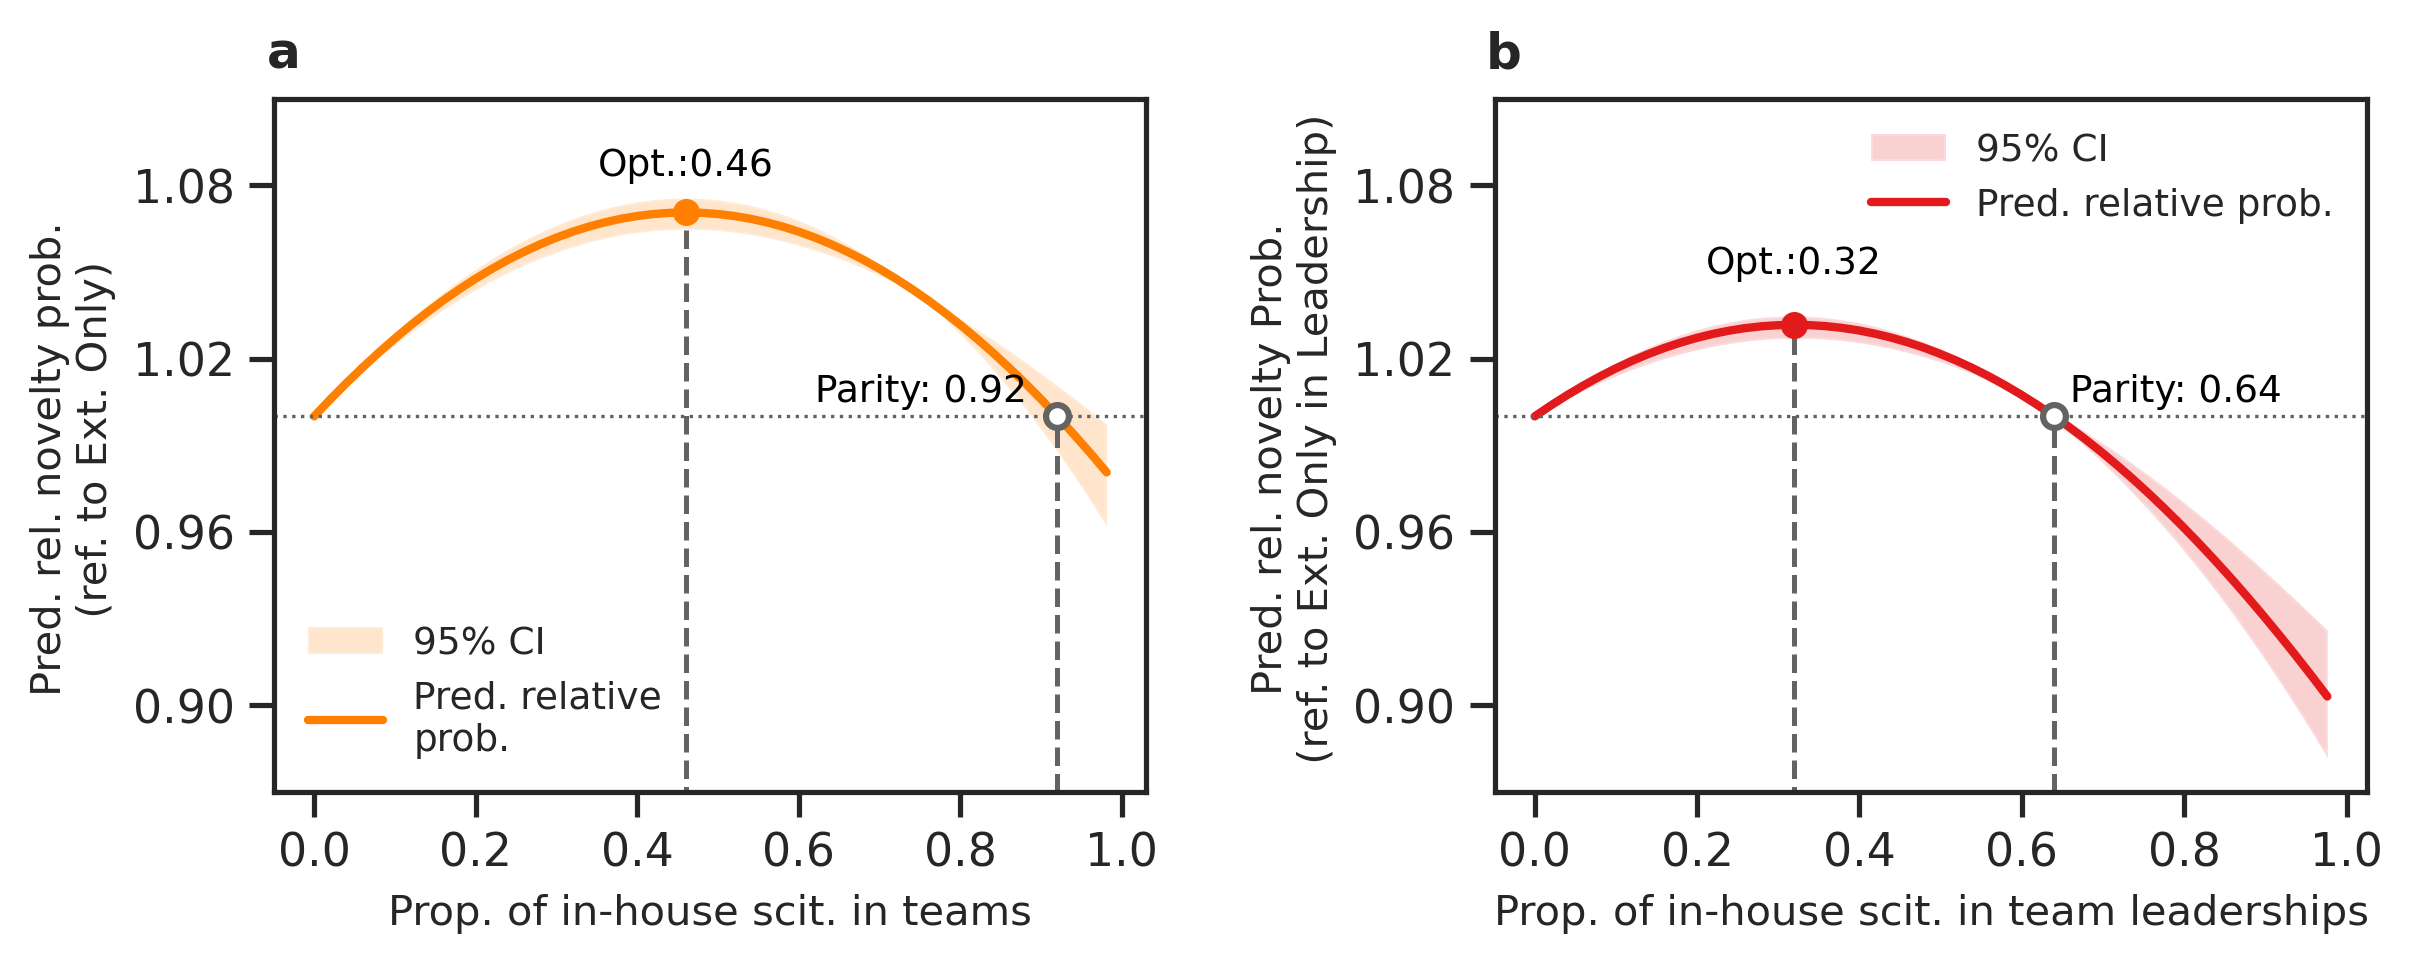

In [32]:
fig = plt.figure(figsize=(9, 3), dpi=300) # 稍微加宽一点以容纳三个点
sns.set(style='ticks', font_scale=1)
outer = gridspec.GridSpec(1, 1, hspace = 0.3)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0], wspace = 0.4)
ax1 = fig.add_subplot(gs1[0])
main_color = '#ff7f00'
df = pro
# 2. 绘制 95% 置信区间的阴影带 (fill_between)
# 这一步要先画，这样阴影会在曲线的下层，不会遮挡实线
ax1.fill_between(
    x=df['ratio_fac_scientist'], y1=df['cl0'], y2=df['ch0'], 
    color=main_color, alpha=0.2, edgecolor=None, label='95% CI')
# 3. 绘制核心预测曲线 (plot)
ax1.plot(df['ratio_fac_scientist'], df['e0'], 
        color=main_color, linewidth=2, label='Pred. relative \nprob.')
peak_idx = df['e0'].idxmax()
optimal_x = df.loc[peak_idx, 'ratio_fac_scientist']
max_y = df.loc[peak_idx, 'e0']
ax1.vlines(x=optimal_x, ymin=-1, ymax=max_y, color='#636363', linestyle='--', linewidth=1.2, alpha=1, zorder=1)
ax1.scatter(optimal_x, max_y, color='#ff7f00', s=30, zorder=5)
ax1.text(x=optimal_x, y=max_y+0.01, s=f'Opt.:{optimal_x:.2f}', # 保留两位小数
        ha='center', va='bottom', fontsize=9, color='black')
# 4. 坐标轴与文字美化
ax1.set_xlabel('Prop. of in-house scit. in teams', fontsize=10)
ax1.set_ylabel('Pred. rel. novelty prob.  \n (ref. to Ext. Only)', fontsize=10)
# 根据你的实际数据概率范围调整 Y 轴，比如:
ax1.set_ylim(0.87, 1.11) 
ax1.axhline(1, color='#636363', linestyle=':', linewidth=0.8) 
ax1.yaxis.set_major_locator(MultipleLocator(0.06))
# 6. 图例设置
ax1.legend(frameon=False, loc='best', fontsize=9)
# 截取顶点右侧的数据 (回落阶段)
df_right = df.loc[peak_idx:].copy()
# 确保曲线确实跌破了 1，防止报错
if (df_right['e0'] <= 1).any():
    # 利用 np.interp 进行线性插值求出精确的 X 坐标。
    # 因为 np.interp 要求输入的自变量必须是递增的，而我们的 e0 在右半段是递减的，所以加上 [::-1] 倒序
    y_vals = df_right['e0'].values[::-1]
    x_vals = df_right['ratio_fac_scientist'].values[::-1]
    cross_x = np.interp(1.0, y_vals, x_vals)
    # 绘制交点及辅助线
    # 画一条向下的点状线 (ymin 与你的坐标轴下限 0.87 保持一致)
    ax1.vlines(x=cross_x, ymin=0.87, ymax=1.0, color='#636363', linestyle='--', linewidth=1.2, zorder=1)
    # 画一个有轮廓的空心点/或者灰色点，与最优值的实心红点做视觉区分
    ax1.scatter(cross_x, 1.0, color='white', edgecolor='#636363', s=30, zorder=5, linewidth=1.5)
    # 添加文字标注 (Parity: 意为平价/均势，表示与基准组等效)
    ax1.text(x=cross_x - 0.3, y=1.0 + 0.015, s=f'Parity: {cross_x:.2f}', 
             ha='left', va='top', fontsize=9, color='black')

ax2 = fig.add_subplot(gs1[1])
df = lro
main_color = '#e31a1c'
# 2. 绘制 95% 置信区间的阴影带 (fill_between)
# 这一步要先画，这样阴影会在曲线的下层，不会遮挡实线
ax2.fill_between(x=df['fac_scientist_lead_ratio'], y1=df['cl0'], y2=df['ch0'], 
                 color=main_color, alpha=0.2, edgecolor=None, label='95% CI')
# 3. 绘制核心预测曲线 (plot)
ax2.plot(df['fac_scientist_lead_ratio'], df['e0'], color=main_color, 
        linewidth=2, label='Pred. relative prob.')
peak_idx = df['e0'].idxmax()
optimal_x = df.loc[peak_idx, 'fac_scientist_lead_ratio']
max_y = df.loc[peak_idx, 'e0']
ax2.vlines(x=optimal_x, ymin=0.05, ymax=max_y, color='#636363', linestyle='--', linewidth=1.2, alpha=1, zorder=1)
ax2.scatter(optimal_x, max_y, color='#e31a1c', s=30, zorder=5)
ax2.text(x=optimal_x, y=max_y + 0.015, s=f'Opt.:{optimal_x:.2f}', # 保留两位小数
        ha='center', va='bottom', fontsize=9, color='black',)
# 4. 坐标轴与文字美化
ax2.set_xlabel('Prop. of in-house scit. in team leaderships', fontsize=10)
ax2.set_ylabel('Pred. rel. novelty Prob.  \n (ref. to Ext. Only in Leadership)', fontsize=10)
# 根据你的实际数据概率范围调整 Y 轴，比如:
ax2.set_ylim(0.87, 1.11) 
ax2.axhline(1, color='#636363', linestyle=':', linewidth=0.8) 
ax2.yaxis.set_major_locator(MultipleLocator(0.06))
# 截取顶点右侧的数据 (回落阶段)
df_right = df.loc[peak_idx:].copy()
# 确保曲线确实跌破了 1，防止报错
if (df_right['e0'] <= 1).any():
    # 利用 np.interp 进行线性插值求出精确的 X 坐标。
    # 因为 np.interp 要求输入的自变量必须是递增的，而我们的 e0 在右半段是递减的，所以加上 [::-1] 倒序
    y_vals = df_right['e0'].values[::-1]
    x_vals = df_right['fac_scientist_lead_ratio'].values[::-1]
    cross_x = np.interp(1.0, y_vals, x_vals)
    # 绘制交点及辅助线
    # 画一条向下的点状线 (ymin 与你的坐标轴下限 0.87 保持一致)
    ax2.vlines(x=cross_x, ymin=0.87, ymax=1.0, color='#636363', linestyle='--', linewidth=1.2, zorder=1)
    # 画一个有轮廓的空心点/或者灰色点，与最优值的实心红点做视觉区分
    ax2.scatter(cross_x, 1.0, color='white', edgecolor='#636363', s=30, zorder=5, linewidth=1.5)
    # 添加文字标注 (Parity: 意为平价/均势，表示与基准组等效)
    ax2.text(x=cross_x + 0.02, y=1.0 + 0.015, s=f'Parity: {cross_x:.2f}', 
             ha='left', va='top', fontsize=9, color='black')

ax2.legend(frameon=False, loc='upper right', fontsize=9)

ax_num = [ax1, ax2,]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(0.03, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right') 
plt.tight_layout()
plt .savefig(main_path + r'GraduationPaper/RevisetoJournal/Figure3.svg', bbox_inches='tight')
plt .show()

# Figure 3 H4

In [33]:
pre_facpub = r'GraduationPaper/RevisetoJournal/R_ex_ld_h4_comp_pre_facpub.csv'
pfp = pd.read_csv(main_path + pre_facpub)
pfp['label'] = pfp['contrast'].map({'mean(Collaboration) / mean(Service)':'In-house scit. Co-leading',
                                    'mean(Participation) / mean(Service)':'In-house scit. Participating'})
pfp .head(3)

,rowid,term,contrast,lnex_ld_avg_before_year_prod_fac,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,label
0,1,CoType,mean(Collaboration) / mean(Service),0.00000,1.058109,0.019753,53.566517,0.0,inf,1.019393,1.096824,0.263794,0.279122,0.263794,In-house scit. Co-leading
1,2,CoType,mean(Collaboration) / mean(Service),0.13593,1.058889,0.018873,56.104805,0.0,inf,1.021897,1.095880,0.262872,0.278352,0.262872,In-house scit. Co-leading
2,3,CoType,mean(Collaboration) / mean(Service),0.27186,1.059670,0.018004,58.858043,0.0,inf,1.024383,1.094957,0.261951,0.277582,0.261951,In-house scit. Co-leading


In [34]:
pre_withinh = r'GraduationPaper/RevisetoJournal/R_ex_ld_h4_comp_pre_withih.csv'
pwi = pd.read_csv(main_path + pre_withinh)
pwi['label'] = pwi['contrast'].map({'mean(Collaboration) / mean(Service)':'In-house scit. Co-leading',
                                    'mean(Participation) / mean(Service)':'In-house scit. Participating'})
pwi .head(4)

,term,contrast,ex_ld_max_before_year_with_ih_bin,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,label
0,CoType,mean(Collaboration) / mean(Service),False,1.183064,0.022747,52.009091,0.000000e+00,inf,1.138480,1.227648,0.246388,0.305991,0.246388,In-house scit. Co-leading
1,CoType,mean(Collaboration) / mean(Service),True,1.038923,0.007496,138.590717,0.000000e+00,inf,1.024231,1.053616,0.285875,0.299394,0.285875,In-house scit. Co-leading
2,CoType,mean(Participation) / mean(Service),False,1.218887,0.037326,32.655032,6.797902e-234,774.566085,1.145729,1.292045,0.246388,0.318177,0.246388,In-house scit. Participating
3,CoType,mean(Participation) / mean(Service),True,0.983190,0.009145,107.506091,0.000000e+00,inf,0.965266,1.001115,0.285875,0.280084,0.285875,In-house scit. Participating


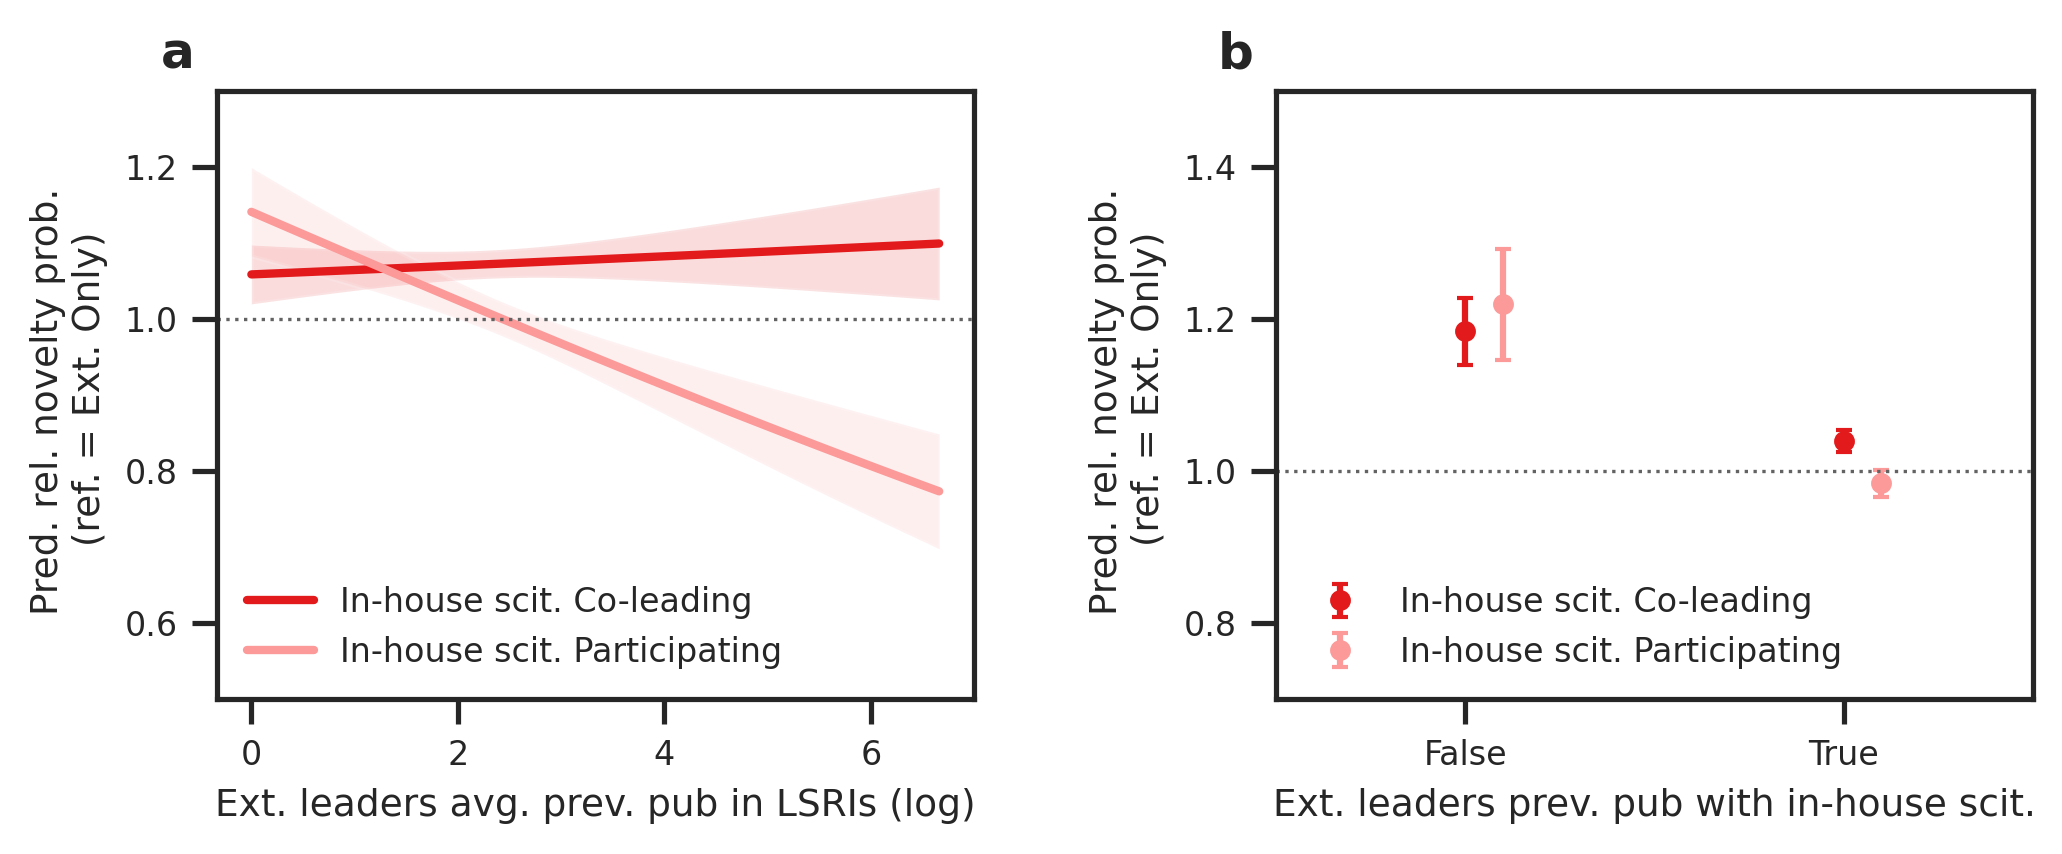

In [35]:
fig = plt.figure(figsize=(7, 3), dpi=300)
sns.set(style='ticks', font_scale=0.9)
outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],wspace = 0.4)
ax_a = fig.add_subplot(gs1[0])
df = pfp
colors = {'In-house scit. Co-leading': '#e31a1c', 'In-house scit. Participating': '#fb9a99'}
label = {'In-house scit. Co-leading': 'In-house scit. Co-leading', 'In-house scit. Participating': 'In-house scit. Participating'}
# 获取分组列表
groups = df['label'].unique()
for group in groups:
    # 提取当前组的数据
    subset = df[df['label'] == group].sort_values('lnex_ld_avg_before_year_prod_fac')
    # 1. 获取绘图数据
    x = subset['lnex_ld_avg_before_year_prod_fac']
    y = subset['estimate']
    y_low = subset['conf.low']
    y_high = subset['conf.high']
    # 获取颜色
    color = colors.get(group, 'black')
    # 2. 绘制主线 (Line) 和 点 (Marker)
    ax_a.plot(x, y, markersize=6, linestyle='-', linewidth=2, label=group, color=color)
    # 3. 绘制误差带 (Ribbon/Band) - 这种比 Errorbar 更适合连续变量
    ax_a.fill_between(x, y_low, y_high, color=color,  alpha=0.15, edgecolor=None)
# 添加 y=0 的参考线 (因为是 % 变化，0 代表无变化)
ax_a.axhline(1, color='#636363', linestyle=':', linewidth=0.8, alpha=1)
# 标签与标题
ax_a.set_xlabel('Ext. leaders avg. prev. pub in LSRIs (log)', fontsize=9)
ax_a.set_ylabel('Pred. rel. novelty prob. \n (ref. = Ext. Only)', fontsize=9)
ax_a.set_ylim(0.5, 1.3) # 稍微调高上限以适应可能的数值
ax_a.yaxis.set_major_locator(MultipleLocator(0.2))
# ax_a.yaxis.set_major_formatter(FuncFormatter(to_percent))
# 图例设置
ax_a.legend(fontsize=8, loc='lower left', frameon=False)
# 坐标轴微调
ax_a.tick_params(axis='both', which='major', labelsize=8)

ax_b = fig.add_subplot(gs1[1])
order = [False,True]
df = pwi
colors = {'In-house scit. Co-leading': '#e31a1c', 'In-house scit. Participating': '#fb9a99'}
label = {'In-house scit. Co-leading': 'In-house scit. Co-leading', 'In-house scit. Participating': 'In-house scit. Participating'}

bar_height = 0.1
x_pos = np.arange(len(order))
for i, term in enumerate(order):
    df_term = df[df['ex_ld_max_before_year_with_ih_bin'] == term]
    for j, otype in enumerate(['In-house scit. Co-leading','In-house scit. Participating']):
        df_otype = df_term[df_term['label'] == otype]
        pos = i + j*bar_height
        ax_b.errorbar(
            pos, df_otype['estimate'].values[0], yerr=[[df_otype['estimate'].values[0] - df_otype['conf.low'].values[0]],
                                                  [df_otype['conf.high'].values[0] - df_otype['estimate'].values[0]]],
            fmt='o', capsize=2, markersize=4, color = colors[otype], label = label[otype]
        )

ax_b.set_xticks(x_pos)
ax_b.set_xticklabels(['False','True'],fontsize = 8,)
# x 轴标签
ax_b.tick_params(axis='y', labelsize=8)
ax_b.set_xlim(-0.5, 1.5)
ax_b.set_xlabel('Ext. leaders prev. pub with in-house scit.', fontsize = 9)
ax_b.set_ylim(0.7, 1.5) # 稍微调高上限以适应可能的数值
ax_b.yaxis.set_major_locator(MultipleLocator(0.2))
# ax_b.yaxis.set_major_formatter(FuncFormatter(to_percent))
ax_b.set_ylabel('Pred. rel. novelty prob. \n (ref. = Ext. Only)', fontsize = 9)
ax_b.axhline(1, color='#636363', linestyle=':', linewidth=0.8)
# 图例
handles, labels = ax_b.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax_b.legend(by_label.values(), by_label.keys(),
           loc='lower left', ncol=1, frameon=False, fontsize = 8)

ax_num = [ax_a, ax_b]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(-0.03, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')   
    
plt.tight_layout()
plt .savefig(main_path + r'GraduationPaper/RevisetoJournal/Figure4.svg', bbox_inches='tight')
plt.show()

In [36]:
pre_facpub_colead = r'GraduationPaper/RevisetoJournal/R_ex_ld_h4c_comp_pre_co_lead.csv'
pfpc = pd.read_csv(main_path + pre_facpub_colead)
pfpc['label'] = pfpc['contrast'].map({'mean(Collaboration) / mean(Service)':'In-house scit. Co-leading',
                                    'mean(Participation) / mean(Service)':'In-house scit. Participating'})
pfpc .head(3)

,rowid,term,contrast,lnex_ld_avg_before_year_co_lead,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,label
0,1,CoType,mean(Collaboration) / mean(Service),0.000000,1.204749,0.018589,64.810525,0.0,inf,1.168315,1.241182,0.206497,0.248777,0.206497,In-house scit. Co-leading
1,2,CoType,mean(Collaboration) / mean(Service),0.118595,1.183889,0.017150,69.033170,0.0,inf,1.150276,1.217501,0.211124,0.249948,0.211124,In-house scit. Co-leading
2,3,CoType,mean(Collaboration) / mean(Service),0.237189,1.163534,0.015799,73.647817,0.0,inf,1.132569,1.194498,0.215827,0.251122,0.215827,In-house scit. Co-leading


In [37]:
pre_facpub_particpation = r'GraduationPaper/RevisetoJournal/R_ex_ld_h4c_comp_pre_participation.csv'
pfpp = pd.read_csv(main_path + pre_facpub_particpation)
pfpp['label'] = pfpp['contrast'].map({'mean(Collaboration) / mean(Service)':'In-house scit. Co-leading',
                                    'mean(Participation) / mean(Service)':'In-house scit. Participating'})
pfpp .head(3)

,rowid,term,contrast,lnex_ld_avg_before_year_participation,estimate,std.error,statistic,p.value,s.value,conf.low,conf.high,predicted_lo,predicted_hi,predicted,label
0,1,CoType,mean(Collaboration) / mean(Service),0.000000,1.143224,0.013666,83.657647,0.0,inf,1.116440,1.170008,0.228004,0.260659,0.228004,In-house scit. Co-leading
1,2,CoType,mean(Collaboration) / mean(Service),0.131803,1.129902,0.012374,91.315346,0.0,inf,1.105650,1.154154,0.230816,0.260799,0.230816,In-house scit. Co-leading
2,3,CoType,mean(Collaboration) / mean(Service),0.263606,1.116786,0.011300,98.828375,0.0,inf,1.094638,1.138934,0.233652,0.260939,0.233652,In-house scit. Co-leading


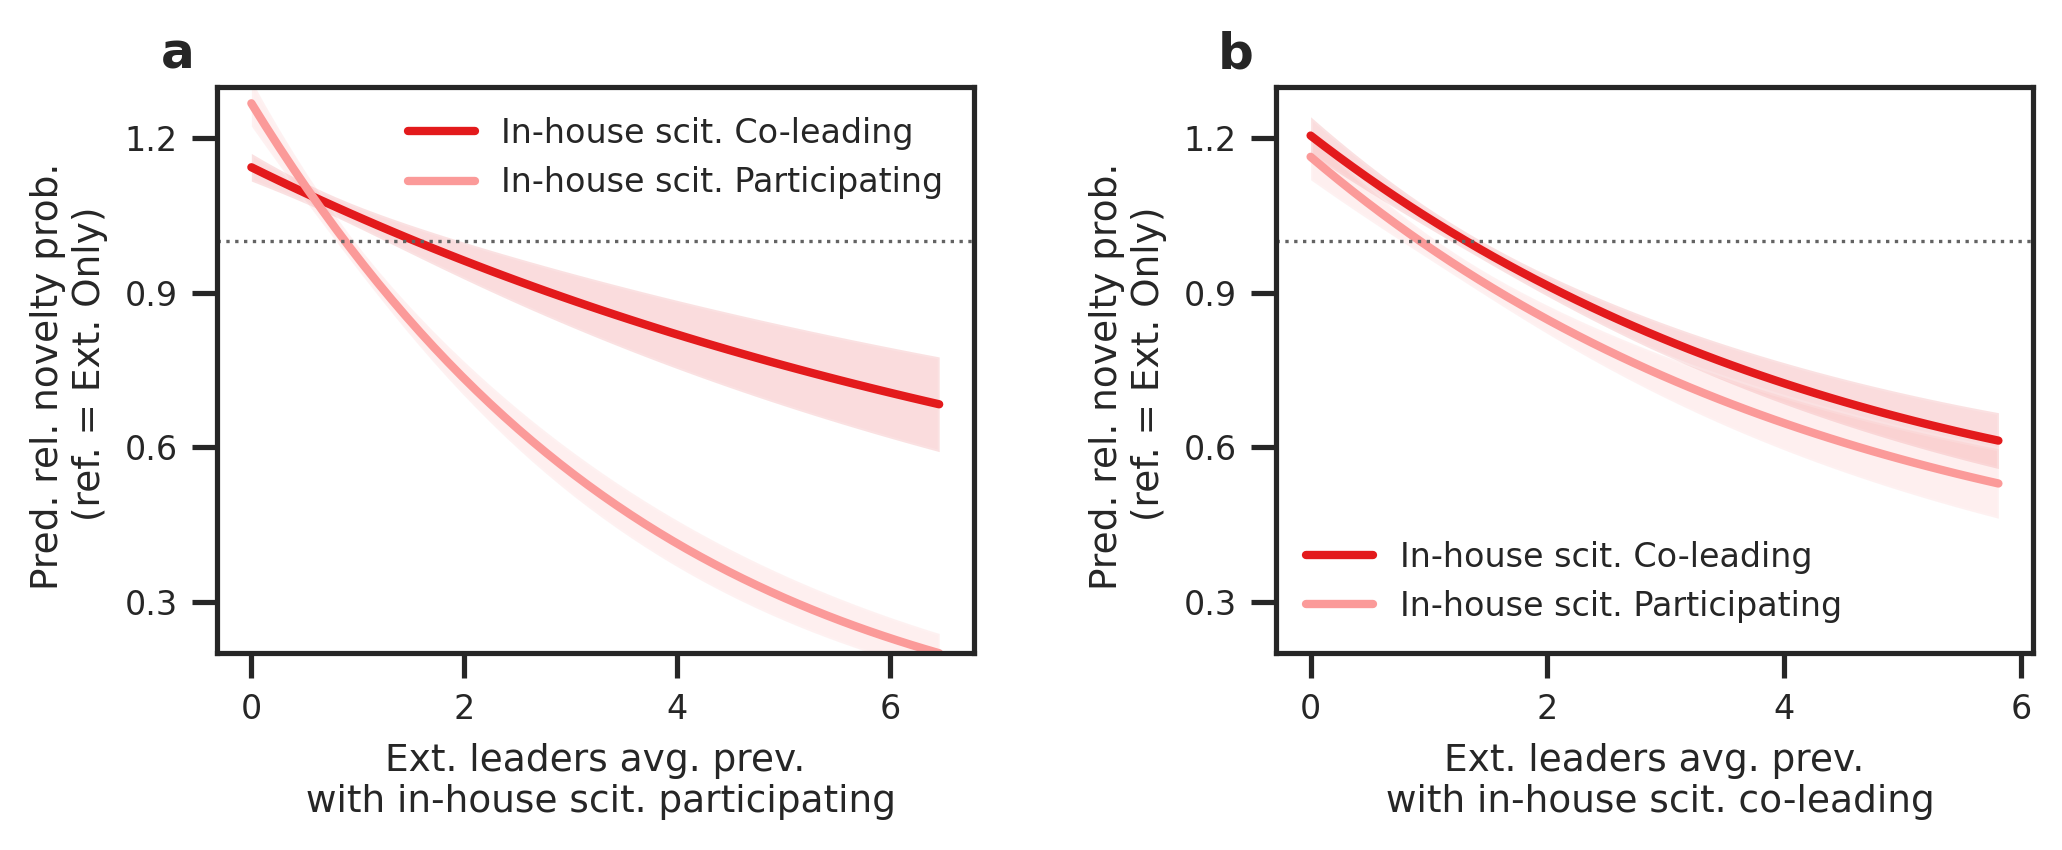

In [38]:
fig = plt.figure(figsize=(7, 3), dpi=300)
sns.set(style='ticks', font_scale=0.9)
outer = gridspec.GridSpec(1, 1)
gs1 = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec=outer[0],wspace = 0.4)
ax_a = fig.add_subplot(gs1[0])
df = pfpp
colors = {'In-house scit. Co-leading': '#e31a1c', 'In-house scit. Participating': '#fb9a99'}
label = {'In-house scit. Co-leading': 'In-house scit. Co-leading', 'In-house scit. Participating': 'In-house scit. Participating'}
# 获取分组列表
groups = df['label'].unique()
for group in groups:
    # 提取当前组的数据
    subset = df[df['label'] == group].sort_values('lnex_ld_avg_before_year_participation')
    # 1. 获取绘图数据
    x = subset['lnex_ld_avg_before_year_participation']
    y = subset['estimate']
    y_low = subset['conf.low']
    y_high = subset['conf.high']
    # 获取颜色
    color = colors.get(group, 'black')
    # 2. 绘制主线 (Line) 和 点 (Marker)
    ax_a.plot(x, y, markersize=6, linestyle='-', linewidth=2, label=group, color=color)
    # 3. 绘制误差带 (Ribbon/Band) - 这种比 Errorbar 更适合连续变量
    ax_a.fill_between(x, y_low, y_high, color=color,  alpha=0.15, edgecolor=None)
# 添加 y=0 的参考线 (因为是 % 变化，0 代表无变化)
ax_a.axhline(1, color='#636363', linestyle=':', linewidth=0.8, alpha=1)
# 标签与标题
ax_a.set_xlabel('Ext. leaders avg. prev.\n with in-house scit. participating', fontsize=9)
ax_a.set_ylabel('Pred. rel. novelty prob. \n (ref. = Ext. Only)', fontsize=9)
ax_a.set_ylim(0.2, 1.3) # 稍微调高上限以适应可能的数值
ax_a.yaxis.set_major_locator(MultipleLocator(0.3))
# ax_a.yaxis.set_major_formatter(FuncFormatter(to_percent))
# 图例设置
ax_a.legend(fontsize=8, loc='upper right', frameon=False)
# 坐标轴微调
ax_a.tick_params(axis='both', which='major', labelsize=8)

ax_b = fig.add_subplot(gs1[1])
df = pfpc
colors = {'In-house scit. Co-leading': '#e31a1c', 'In-house scit. Participating': '#fb9a99'}
label = {'In-house scit. Co-leading': 'In-house scit. Co-leading', 'In-house scit. Participating': 'In-house scit. Participating'}
# 获取分组列表
groups = df['label'].unique()
for group in groups:
    # 提取当前组的数据
    subset = df[df['label'] == group].sort_values('lnex_ld_avg_before_year_co_lead')
    # 1. 获取绘图数据
    x = subset['lnex_ld_avg_before_year_co_lead']
    y = subset['estimate']
    y_low = subset['conf.low']
    y_high = subset['conf.high']
    # 获取颜色
    color = colors.get(group, 'black')
    # 2. 绘制主线 (Line) 和 点 (Marker)
    ax_b.plot(x, y, markersize=6, linestyle='-', linewidth=2, label=group, color=color)
    # 3. 绘制误差带 (Ribbon/Band) - 这种比 Errorbar 更适合连续变量
    ax_b.fill_between(x, y_low, y_high, color=color,  alpha=0.15, edgecolor=None)
# 添加 y=0 的参考线 (因为是 % 变化，0 代表无变化)
ax_b.axhline(1, color='#636363', linestyle=':', linewidth=0.8, alpha=1)
# 标签与标题
ax_b.set_xlabel('Ext. leaders avg. prev.\n with in-house scit. co-leading', fontsize=9)
ax_b.set_ylabel('Pred. rel. novelty prob. \n (ref. = Ext. Only)', fontsize=9)
ax_b.set_ylim(0.2, 1.3) # 稍微调高上限以适应可能的数值
ax_b.yaxis.set_major_locator(MultipleLocator(0.3))
ax_b.xaxis.set_major_locator(MultipleLocator(2))
# ax_b.yaxis.set_major_formatter(FuncFormatter(to_percent))
# 图例设置
ax_b.legend(fontsize=8, loc='lower left', frameon=False)
# 坐标轴微调
ax_b.tick_params(axis='both', which='major', labelsize=8)

ax_num = [ax_a, ax_b]
labels = list(string.ascii_lowercase)
for i, ax in enumerate(ax_num):
    ax.text(-0.03, 1.1, labels[i], transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top', ha='right')   
    
plt.tight_layout()
plt .savefig(main_path + r'GraduationPaper/RevisetoJournal/Figure4_sm.svg', bbox_inches='tight')
plt.show()